## Week 8 — Neural Network + MC Dropout EI + Interior Penalty (6D)

**Approach**: Train a compact neural network surrogate (6→5→5→1), compute Expected Improvement via MC Dropout (50 stochastic forward passes), and apply a multiplicative interior penalty to discourage boundary-hugging candidates. Since all F7 outputs are positive (EI ≥ 0, w ∈ [0.01, 1.0]), multiplicative `penalised_EI = EI × w(x)` works correctly.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Architecture | 6→5→5→1 (2L×5N) | Compact for 38 samples (71 params) |
| Learning rate | 0.005 | Moderate for Adam on small network |
| Dropout | 0.1 | 5-node layers can't afford 20% capacity loss |
| Epochs | 200 | 71 params converge fast; longer risks memorisation |
| MC samples | 50 | Sufficient for EI ranking |
| Candidates | 20,000 | Good coverage in 6D |
| STEEPNESS | 0.1 | 6D product already strong; gentle per-dim decay |
| FLOOR | 0.01 | Prevents zero-weight at boundaries |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
# ── Constants ──
LEARNING_RATE  = 0.005
EPOCHS         = 200
DROPOUT        = 0.1
MC_SAMPLES     = 50
N_CANDIDATES   = 20_000
STEEPNESS      = 0.1
FLOOR          = 0.01
DIM            = 6
GRID_RES       = 50

hyperparam_names = ['learning_rate', 'reg_strength', 'n_layers', 'dropout', 'batch_size', 'optimizer']

print("Constants configured:")
print(f"  DIM={DIM}, LEARNING_RATE={LEARNING_RATE}, EPOCHS={EPOCHS}, DROPOUT={DROPOUT}")
print(f"  MC_SAMPLES={MC_SAMPLES}, N_CANDIDATES={N_CANDIDATES:,}")
print(f"  STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"  Hyperparams: {hyperparam_names}")

Constants configured:
  DIM=6, LEARNING_RATE=0.005, EPOCHS=200, DROPOUT=0.1
  MC_SAMPLES=50, N_CANDIDATES=20,000
  STEEPNESS=0.1, FLOOR=0.01
  Hyperparams: ['learning_rate', 'reg_strength', 'n_layers', 'dropout', 'batch_size', 'optimizer']


In [3]:
# ── Data Loading & Z-Score Normalisation (Week 8) ──
X_raw = np.load('../../data/f7/updated_inputs - Week 8.npy')
y_raw = np.load('../../data/f7/updated_outputs - Week 8.npy')

assert X_raw.shape == (38, 6), f"Expected (38, 6), got {X_raw.shape}"
assert y_raw.shape == (38,), f"Expected (38,), got {y_raw.shape}"
assert np.all(y_raw > 0), "All F7 outputs should be positive"

# Z-score normalisation
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-8
y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-8

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

# Torch tensors for NN training
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

print(f"Week 8 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed: {y_raw.max():.6f} at sample {y_raw.argmax()} ({X_raw[y_raw.argmax()]})")
print(f"\nDimensions: {', '.join(hyperparam_names)}")
print(f"Normalisation: X_mean={np.round(X_mean, 4)}, X_std={np.round(X_std, 4)}")
print(f"               y_mean={y_mean:.6f}, y_std={y_std:.6f}")

# Per-dimension ranges
print(f"\nPer-dimension ranges:")
for i, name in enumerate(hyperparam_names):
    lo, hi = X_raw[:, i].min(), X_raw[:, i].max()
    print(f"  x{i} ({name:>14s}): [{lo:.6f}, {hi:.6f}]")

Week 8 Data: 38 samples, 6 dimensions
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at sample 33 ([0.       0.261823 0.623526 0.173633 0.3524   0.687293])

Dimensions: learning_rate, reg_strength, n_layers, dropout, batch_size, optimizer
Normalisation: X_mean=[0.4218 0.3997 0.4264 0.4561 0.445  0.5229], X_std=[0.3254 0.2482 0.2952 0.3056 0.2869 0.257 ]
               y_mean=0.424607, y_std=0.571197

Per-dimension ranges:
  x0 ( learning_rate): [0.000000, 0.942451]
  x1 (  reg_strength): [0.011813, 0.924694]
  x2 (      n_layers): [0.003635, 0.980389]
  x3 (       dropout): [0.036612, 0.961017]
  x4 (    batch_size): [0.014944, 0.998655]
  x5 (     optimizer): [0.051100, 0.951014]


### Neural Network Surrogate — 6→5→5→1

- **Architecture**: `SurrogateNN` — 2 hidden layers of 5 neurons each (71 parameters)
- **Activation**: ReLU + Dropout(0.1) after each hidden layer
- **Optimiser**: Adam(lr=0.005), MSE loss, 200 epochs
- **Seed**: `torch.manual_seed(42)` for reproducibility
- **R² validation**: Computed on original (un-normalised) scale

Architecture: 6→5→5→1, Parameters: 71
  Epoch 40/200, Loss: 0.673716
  Epoch 80/200, Loss: 0.616788
  Epoch 120/200, Loss: 0.585637
  Epoch 160/200, Loss: 0.510297
  Epoch 200/200, Loss: 0.425602


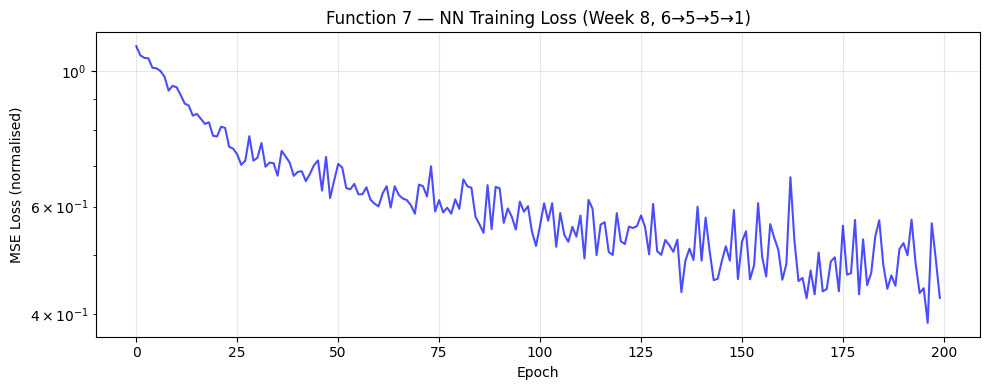


Training R²: 0.637941


In [4]:
# ── Define & Train Neural Network ──
class SurrogateNN(nn.Module):
    """Compact NN surrogate: 6→5→5→1 (71 parameters)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = SurrogateNN()
n_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: 6→5→5→1, Parameters: {n_params}")

# Train with Adam, MSE loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (normalised)')
plt.title('Function 7 — NN Training Loss (Week 8, 6→5→5→1)')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout(); plt.show()

# Training R² on original scale
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_raw - train_pred_orig)**2) / np.sum((y_raw - y_raw.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

In [5]:
# ── MC Dropout EI + Interior Penalty ──

# 1. Generate random candidates in [0,1]⁶
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, DIM))

# 2. Normalise candidates and run MC Dropout forward passes
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

model.train()  # enable dropout for MC sampling
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

# 3. Un-normalise predictions to original scale
mc_preds_orig = np.array(mc_predictions) * y_std + y_mean  # (50, 20000)
mu = mc_preds_orig.mean(axis=0)     # (20000,) - MC mean
sigma = mc_preds_orig.std(axis=0)   # (20000,) - MC std

# 4. Compute EI via sample-then-average (non-parametric)
y_best = y_raw.max()
ei = np.mean(np.maximum(mc_preds_orig - y_best, 0), axis=0)  # (20000,)

# 5. Compute interior penalty weight
#    w(x) = FLOOR + (1-FLOOR) · ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * candidates) ** (2 * STEEPNESS), axis=1
)  # (20000,)

assert interior_weight.min() >= FLOOR - 1e-10, f"Min weight {interior_weight.min()} < FLOOR"
assert interior_weight.max() <= 1.0 + 1e-10, f"Max weight {interior_weight.max()} > 1.0"

# 6. Multiplicative penalty: penalised_EI = EI × w(x)
#    Works because all F7 outputs are positive → EI ≥ 0
penalised_ei = ei * interior_weight

# 7. Select best candidate (with fallback)
raw_best_idx = np.argmax(ei)
if penalised_ei.max() > 0:
    best_idx = np.argmax(penalised_ei)
else:
    # Fallback: all EI = 0 → pick most interior candidate for exploration
    best_idx = np.argmax(interior_weight)
    print("⚠ All EI = 0 — fallback to most interior candidate")

best_point = candidates[best_idx]
assert np.all(best_point >= 0) and np.all(best_point <= 1), "best_point out of [0,1]"

# 8. Report results
penalty_changed = (best_idx != raw_best_idx)
print("=== MC Dropout EI + Interior Penalty (Week 8) ===")
print(f"  y_best (observed)    = {y_best:.6f}")
print(f"  EI range             = [{ei.min():.6f}, {ei.max():.6f}]")
print(f"  Penalty weight range = [{interior_weight.min():.4f}, {interior_weight.max():.4f}]")
print(f"  Penalised EI range   = [{penalised_ei.min():.6f}, {penalised_ei.max():.6f}]")
print(f"\n  Raw EI best:        idx={raw_best_idx}, EI={ei[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.4f}")
print(f"  Penalised EI best:  idx={best_idx}, EI={ei[best_idx]:.6f}, w={interior_weight[best_idx]:.4f}")
print(f"  Predicted mean (μ)  = {mu[best_idx]:.6f}")
print(f"  Predicted std (σ)   = {sigma[best_idx]:.6f}")
print(f"\n  Penalty changed selection: {'YES ✓' if penalty_changed else 'NO — same candidate'}")
print(f"  Best point: {best_point}")

⚠ All EI = 0 — fallback to most interior candidate
=== MC Dropout EI + Interior Penalty (Week 8) ===
  y_best (observed)    = 2.304991
  EI range             = [0.000000, 0.000000]
  Penalty weight range = [0.0342, 0.9835]
  Penalised EI range   = [0.000000, 0.000000]

  Raw EI best:        idx=0, EI=0.000000, w=0.4732
  Penalised EI best:  idx=6239, EI=0.000000, w=0.9835
  Predicted mean (μ)  = 0.406467
  Predicted std (σ)   = 0.146990

  Penalty changed selection: YES ✓
  Best point: [0.50505163 0.56448574 0.45259003 0.45803555 0.58965013 0.52635351]


In [6]:
# ── Feature Importance via Input Gradients ──
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()

top2 = np.argsort(grad_importance)[-2:]  # indices of two most important dims

print("=== Feature Importance (Input Gradient Magnitude, Week 8) ===")
for i, imp in enumerate(grad_importance):
    bar = '█' * int(imp * 40)
    marker = ' ◄ top-2' if i in top2 else ''
    print(f"  x{i} ({hyperparam_names[i]:>14s}): {imp:.4f} {bar}{marker}")

=== Feature Importance (Input Gradient Magnitude, Week 8) ===
  x0 ( learning_rate): 0.2349 █████████ ◄ top-2
  x1 (  reg_strength): 0.0691 ██
  x2 (      n_layers): 0.1805 ███████
  x3 (       dropout): 0.1426 █████
  x4 (    batch_size): 0.2225 ████████ ◄ top-2
  x5 (     optimizer): 0.1504 ██████


Top-2 dims: x4 (batch_size), x0 (learning_rate)
Fixed: x1=0.2618, x2=0.6235, x3=0.1736, x5=0.6873


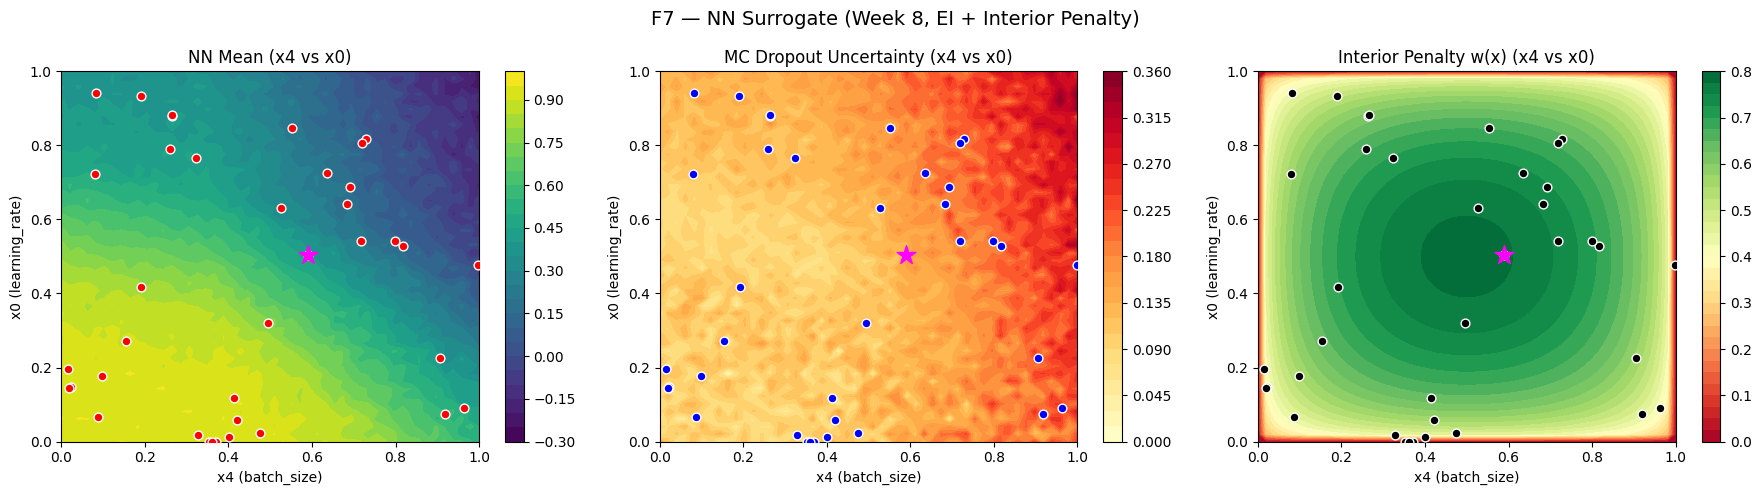

In [7]:
# ── 3-Panel Visualisation (NN Mean, MC Uncertainty, Interior Penalty) ──
fixed_dims = [d for d in range(DIM) if d not in top2]
best_obs = X_raw[y_raw.argmax()]

print(f"Top-2 dims: x{top2[0]} ({hyperparam_names[top2[0]]}), x{top2[1]} ({hyperparam_names[top2[1]]})")
print(f"Fixed: " + ", ".join(f"x{d}={best_obs[d]:.4f}" for d in fixed_dims))

# Build grid on top-2 dimensions
g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.zeros((GRID_RES * GRID_RES, DIM))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()
for d in fixed_dims:
    grid_pts[:, d] = best_obs[d]

# MC Dropout predictions on grid
grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # enable dropout
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(GRID_RES, GRID_RES)
grid_sigma = grid_mc.std(axis=0).reshape(GRID_RES, GRID_RES)

# Interior penalty on grid
grid_penalty = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * grid_pts) ** (2 * STEEPNESS), axis=1
).reshape(GRID_RES, GRID_RES)

# Plot 3 panels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: NN Mean
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap='viridis')
axes[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='red', edgecolors='white', s=40, zorder=5)
axes[0].scatter(best_point[top2[0]], best_point[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[0].set_title(f"NN Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[0].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c1, ax=axes[0])

# Panel 2: MC Dropout Uncertainty
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap='YlOrRd')
axes[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='blue', edgecolors='white', s=40, zorder=5)
axes[1].scatter(best_point[top2[0]], best_point[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[1].set_title(f"MC Dropout Uncertainty (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[1].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Interior Penalty Heatmap
c3 = axes[2].contourf(G0, G1, grid_penalty, levels=30, cmap='RdYlGn')
axes[2].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='black', edgecolors='white', s=40, zorder=5)
axes[2].scatter(best_point[top2[0]], best_point[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[2].set_title(f"Interior Penalty w(x) (x{top2[0]} vs x{top2[1]})")
axes[2].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[2].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c3, ax=axes[2])

plt.suptitle("F7 — NN Surrogate (Week 8, EI + Interior Penalty)", fontsize=14)
plt.tight_layout()
plt.show()

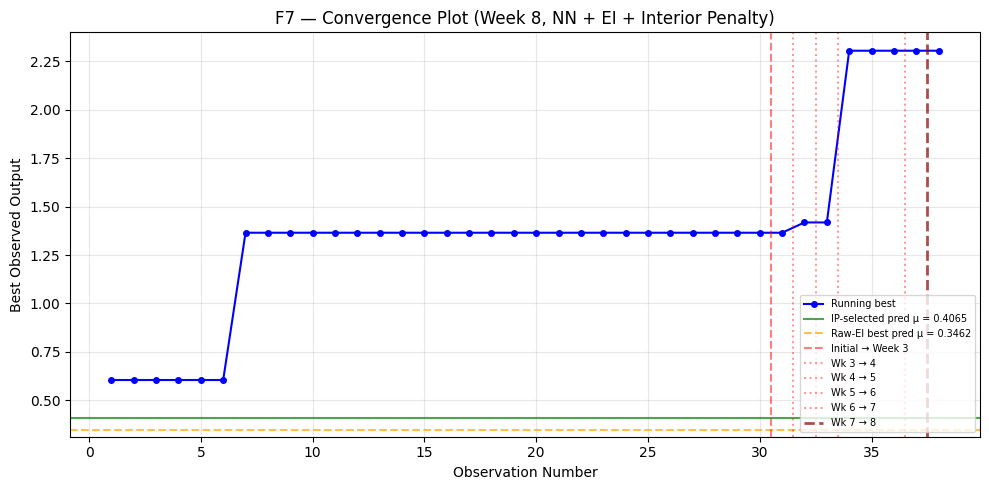

Running best at Week 7 end (sample 37): 2.304991
Running best at Week 8 end (sample 38): 2.304991
IP-selected predicted mean: 0.406467
Penalty changed selection: YES ✓


In [8]:
# ── Convergence Plot ──
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), running_best, 'b-o', markersize=4, linewidth=1.5, label='Running best')

# IP-selected candidate predicted mean
plt.axhline(y=mu[best_idx], color='green', linestyle='-', alpha=0.7,
            label=f'IP-selected pred μ = {mu[best_idx]:.4f}')
# Raw-EI best candidate predicted mean (comparison)
plt.axhline(y=mu[raw_best_idx], color='orange', linestyle='--', alpha=0.7,
            label=f'Raw-EI best pred μ = {mu[raw_best_idx]:.4f}')

# Weekly data boundaries
plt.axvline(x=30.5, color="red", linestyle="--", alpha=0.5, label="Initial → Week 3")
plt.axvline(x=31.5, color="red", linestyle=":", alpha=0.4, label="Wk 3 → 4")
plt.axvline(x=32.5, color="red", linestyle=":", alpha=0.4, label="Wk 4 → 5")
plt.axvline(x=33.5, color="red", linestyle=":", alpha=0.4, label="Wk 5 → 6")
plt.axvline(x=36.5, color="red", linestyle=":", alpha=0.4, label="Wk 6 → 7")
plt.axvline(x=37.5, color="darkred", linestyle="--", linewidth=2, alpha=0.7, label="Wk 7 → 8")

plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("F7 — Convergence Plot (Week 8, NN + EI + Interior Penalty)")
plt.legend(loc='lower right', fontsize=7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 7 end (sample 37): {running_best[36]:.6f}")
print(f"Running best at Week 8 end (sample 38): {running_best[-1]:.6f}")
print(f"IP-selected predicted mean: {mu[best_idx]:.6f}")
print(f"Penalty changed selection: {'YES ✓' if penalty_changed else 'NO'}")

In [9]:
# ── Submission Query ──
submission_point = np.clip(best_point, 0.0, 0.999999)
submission_query = "-".join(f"{v:.6f}" for v in submission_point)

print("=" * 60)
print("WEEK 8 SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"\n  {submission_query}\n")
print("=" * 60)

# Format validation
parts = submission_query.split("-")
assert len(parts) == 6, f"Expected 6 dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"
print("✓ Submission format validated (6 dims, all in [0, 0.999999])")

# Hyperparameter metadata
print(f"\n── Hyperparameters ──")
print(f"  Architecture: 6→5→5→1 ({n_params} params)")
print(f"  Learning rate: {LEARNING_RATE}, Dropout: {DROPOUT}, Epochs: {EPOCHS}")
print(f"  MC samples: {MC_SAMPLES}, Candidates: {N_CANDIDATES:,}")
print(f"  STEEPNESS: {STEEPNESS}, FLOOR: {FLOOR}")
print(f"  Training R²: {train_r2:.6f}")

# Penalty effect
print(f"\n── Penalty Effect ──")
print(f"  Raw EI best:       [{'-'.join(f'{v:.6f}' for v in candidates[raw_best_idx])}]")
print(f"    EI={ei[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.4f}, penalised={penalised_ei[raw_best_idx]:.6f}")
print(f"  IP-selected:       [{'-'.join(f'{v:.6f}' for v in best_point)}]")
print(f"    EI={ei[best_idx]:.6f}, w={interior_weight[best_idx]:.4f}, penalised={penalised_ei[best_idx]:.6f}")
print(f"  Selection changed: {'YES ✓' if penalty_changed else 'NO'}")

# Per-dimension breakdown
print(f"\n── Per-Dimension Coordinates ──")
for i, (name, val) in enumerate(zip(hyperparam_names, submission_point)):
    print(f"  x{i} ({name:>14s}): {val:.6f}")

WEEK 8 SUBMISSION QUERY FOR FUNCTION 7

  0.505052-0.564486-0.452590-0.458036-0.589650-0.526354

✓ Submission format validated (6 dims, all in [0, 0.999999])

── Hyperparameters ──
  Architecture: 6→5→5→1 (71 params)
  Learning rate: 0.005, Dropout: 0.1, Epochs: 200
  MC samples: 50, Candidates: 20,000
  STEEPNESS: 0.1, FLOOR: 0.01
  Training R²: 0.637941

── Penalty Effect ──
  Raw EI best:       [0.374540-0.950714-0.731994-0.598658-0.156019-0.155995]
    EI=0.000000, w=0.4732, penalised=0.000000
  IP-selected:       [0.505052-0.564486-0.452590-0.458036-0.589650-0.526354]
    EI=0.000000, w=0.9835, penalised=0.000000
  Selection changed: YES ✓

── Per-Dimension Coordinates ──
  x0 ( learning_rate): 0.505052
  x1 (  reg_strength): 0.564486
  x2 (      n_layers): 0.452590
  x3 (       dropout): 0.458036
  x4 (    batch_size): 0.589650
  x5 (     optimizer): 0.526354
